In [2]:
import numpy as np
from scipy.special import logsumexp

# p_data 
It is given by a mixture of product distributions.
The marginal distribution is independently drawn from a symmetric Dirichlet distribution.

In [3]:


def entropy(p):
    """
    Converts a probability vector p into its entropy H(p)=-\sum_i p_i \log(p_i).
    """
    p = np.asarray(p, float)
    p = p / p.sum()
    return -np.sum(p * np.log(p + 1e-12))


def generate_mixture_parameters_dir(r, N, L, alpha, rng=None):
    """
    Generate parameters for a mixture of r product distributions over N variables
    with L states each. Each product component has independent Dirichlet(alpha) marginals.

    r: Number of mixture components
    N: Number of coordinates (dimensions)
    L: Number of discrete values each coorinate can take {0, ..., L-1}
    alpha: Total concentration parameter for Dirichlet distributions
    rng: Optional random number generator

    return tuple (w, mu) where
    w: shape (r,), mixture weights summing to 1
    mu: shape (r, N, L), mixture component marginals, for each component i, coordinate j,
            mu[i,j,:] ~ Dirichlet(alpha_vec) where alpha_vec = (alpha/L, ..., alpha/L)
    """
    if rng is None:
        rng = np.random.default_rng()


    w = np.full(r, 1.0 / r)

    # mu: shape (r, N, L), each entry is Dirichlet(alpha)
    mu = np.empty((r, N, L))
    alpha_vec = np.full(L, alpha/L)
    for i in range(r):
        for j in range(N):
            mu[i, j] = rng.dirichlet(alpha_vec)

    return w, mu



def sample_from_pi(w, mu, rng=None):
    """
    Sample x from the true mixture q(x) = sum_i w_i ∏_j mu[i,j,x_j].

    w: shape (r,)
    mu: shape (r, N, L)
    """
    if rng is None:
        rng = np.random.default_rng()

    w = np.asarray(w)
    mu = np.asarray(mu)
    r, N, L = mu.shape

    # pick mixture component
    i = rng.choice(r, p=w)

    # sample each coordinate independently
    x = np.empty(N, dtype=int)
    for j in range(N):
        x[j] = rng.choice(L, p=mu[i, j])

    return x



def log_pi_of_x(x, w, mu):
    """
    Compute log π(x) for π(x) = sum_i w_i ∏_j μ_j^{(i)}(x_j).

    (Using the log-sum-exp trick for numerical stability)
    """
    x = np.asarray(x, int)
    w = np.asarray(w, float)
    mu = np.asarray(mu, float)

    r, N, L = mu.shape
    assert x.shape == (N,)

    log_w = np.log(w)
    log_mu = np.log(mu)

    log_comp = log_w.copy()
    for i in range(r):
        log_comp[i] += log_mu[i, np.arange(N), x].sum()

    m = log_comp.max()
    return m + np.log(np.exp(log_comp - m).sum())


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/1g/hzsypj410kvbd11488dqcsz80000gn/T/ipykernel_87765/4061688213.py:3: SyntaxWarning: invalid escape sequence '\s'
  Converts a probability vector p into its entropy H(p)=-\sum_i p_i \log(p_i).


## understand this


In [4]:
def log_qt_of_xt(x_t, w, mu, beta, t, MASK=-1):
    """
    Compute log q_t(x_t) for the absorbing state process with mixture p_data.
    
    log q_t(x_t) = log[ e^{-beta*t*|M^c|} * (1-e^{-beta*t})^{|M|} 
                        * sum_i w_i * prod_{j not in M} mu_{i,j}(x_t^j) ]
    """
    x_t = np.asarray(x_t, int)
    unmasked = [j for j in range(len(x_t)) if x_t[j] != MASK]
    masked = [j for j in range(len(x_t)) if x_t[j] == MASK]
    
    alpha_t = np.exp(-beta * t)
    
    # temporal factor
    log_temporal = len(unmasked) * np.log(alpha_t) + \
                   len(masked) * np.log(1 - alpha_t)
    
    # data factor: sum_i w_i * prod_{j not in M} mu_{i,j}(x_t^j)
    log_w = np.log(np.clip(w, 1e-300, None))
    log_mu = np.log(np.clip(mu, 1e-300, None))
    log_comp = log_w.copy()
    for i in range(len(w)):
        log_comp[i] += log_mu[i, unmasked, x_t[unmasked]].sum()
    m = log_comp.max()
    log_data = m + np.log(np.exp(log_comp - m).sum())
    
    return log_temporal + log_data

# Correctors

## Campbell et al. "Random masking"

In [5]:
def corrector_step_rm(x_t, mu, beta, tau_c, n_corrector, rng):
    """
    Apply n_corrector corrector steps using the forward rate R_t only.
    
    For the absorbing process, the corrector rate R^c_t = R_t + R_hat_t
    reduces to just R_t in practice, since R_hat_t cannot correct already
    unmasked tokens. R_t allows unmasked tokens to be re-masked at rate beta,
    giving the predictor a chance to fix mistakes on the next step.
    
    Omega is NOT updated during corrector steps since no unmasking occurs.
    The caller is responsible for recomputing omega after all corrector steps
    using the updated x_t.
    
    Parameters
    ----------
    x_t : np.ndarray, shape (N,)
        Current sequence state, with MASK=-1.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals. Only used for shape reference.
    beta : float
        Forward masking rate.
    tau_c : float
        Corrector step size.
    n_corrector : int
        Number of corrector steps to apply.
    rng : np.random.Generator
    
    Returns
    -------
    x_t : np.ndarray, shape (N,)
        Updated sequence after corrector steps, with some tokens re-masked.
    """
    MASK = -1

    for _ in range(n_corrector):
        unmasked = [j for j in range(len(x_t)) if x_t[j] != MASK]

        # collect re-masking transitions before applying simultaneously
        to_remask = []
        for j in unmasked:
            n = rng.poisson(tau_c * beta)
            if n > 0:
                to_remask.append(j)

        # apply all re-maskings simultaneously
        for j in to_remask:
            x_t[j] = MASK

    return x_t

# Reverse Transition Rate Kernel
$\beta$ is the rate for each token to be transitioned to [MASK]. 

$\beta = 1/N$ 

That means $R_j(x, [MASK]) = \beta$ given that $x \neq [MASK]$

In [6]:
def compute_conditionals_and_entropies(omega, mu, masked_list):
    """
    For each j in masked_list compute the predictive marginal and entropy:
      p_j(l) = sum_i omega_i * mu_{i,j}(l)
      H_j    = -sum_l p_j(l) log p_j(l)

    Parameters
    ----------
    omega       : (r,) posterior over mixture components
    mu          : (r, N, L)
    masked_list : list of still-masked coordinate indices

    Returns
    -------
    probs        : dict {j: (L,) array}
    entropies    : dict {j: float}
    sorted_masked: masked_list sorted by increasing H_j
    """
    probs, entropies = {}, {}
    for j in masked_list:
        p_j = np.clip(omega @ mu[:, j, :], 1e-300, None)
        probs[j] = p_j
        entropies[j] = float(-np.sum(p_j * np.log(p_j)))
    sorted_masked = sorted(masked_list, key=lambda j: entropies[j])
    return probs, entropies, sorted_masked

In [7]:
# def _update_omega(omega, mu, block, x_vals):
#     """
#     Bayesian reweighting of the mixture posterior after revealing x_vals.

#       omega_i  <-  omega_i * prod_{j in block} mu_{i,j}(x_j)   (normalised)
#     """
#     log_w = np.log(np.clip(omega, 1e-300, None))
#     for j in block:
#         log_w += np.log(np.clip(mu[:, j, x_vals[j]], 1e-300, None))
#     log_w -= logsumexp(log_w)
#     return np.exp(log_w)


def _update_omega(omega, mu, block, x_vals, w=None, recompute=False):
    """
    Bayesian reweighting of the mixture posterior after revealing x_vals.
    
    Two modes:
    - recompute=False (default): incremental update, multiplies current omega
      by the likelihood of the newly revealed tokens in block:
        omega_i <- omega_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    - recompute=True: recomputes omega from scratch starting from prior w,
      using all coordinates in block. Used after corrector steps where some
      tokens may have been re-masked and omega needs to be resynced.
        omega_i <- w_i * prod_{j in block} mu_{i,j}(x_j)  (normalised)
    
    Parameters
    ----------
    omega : np.ndarray, shape (r,)
        Current mixture posterior.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    block : list of int
        Coordinate indices to condition on.
    x_vals : np.ndarray, shape (N,)
        Current sequence state, used to look up x_vals[j] for j in block.
    w : np.ndarray, shape (r,), optional
        Prior mixture weights. Required if recompute=True.
    recompute : bool
        If True, recompute omega from scratch using prior w.
        If False, incrementally update current omega.
    
    Returns
    -------
    omega : np.ndarray, shape (r,)
        Updated (or recomputed) posterior weights.
    """
    if recompute:
        assert w is not None, "w must be provided when recompute=True"
        log_w = np.log(np.clip(w, 1e-300, None))
    else:
        log_w = np.log(np.clip(omega, 1e-300, None))
    
    for j in block:
        log_w += np.log(np.clip(mu[:, j, x_vals[j]], 1e-300, None))
    
    log_w -= logsumexp(log_w)
    return np.exp(log_w)

In [8]:
# def tau_leaping_reverse_with_logq(w, mu, beta, T, tau, x_given=None, rng=None):
#     """
#     Simulate reverse process using tau leaping and track log q(x).
    
#     If x_given is provided, the function runs in EVALUATION mode:
#     it uses the given token values when unmasking coordinates, but
#     still tracks the log probability of those choices under p_j.
#     This allows computing log q(x) for a fixed x ~ pi, needed for
#     KL estimation.
    
#     If x_given is None, runs in GENERATION mode: tokens are sampled
#     freely from p_j.
    
#     Parameters
#     ----------
#     w : np.ndarray, shape (r,)
#         Prior mixture weights.
#     mu : np.ndarray, shape (r, N, L)
#         Mixture component marginals.
#     beta : float
#         Constant forward masking rate.
#     T : float
#         Terminal time of forward process.
#     tau : float
#         Tau leaping step size.
#     x_given : dict {j: int} or None
#         If provided, fixes the token values for evaluation mode.
#     rng : np.random.Generator, optional
    
#     Returns
#     -------
#     x_t : np.ndarray, shape (N,)
#         Generated (or evaluated) sequence.
#     log_q : float
#         Estimated log q(x) = sum_j log p_j(x^j) at time of unmasking.
#     """
#     if rng is None:
#         rng = np.random.default_rng()
    
#     MASK = -1
#     r, N, L = mu.shape
    
#     x_t = np.full(N, MASK)
#     omega = w.copy()
#     log_q = 0.0  # accumulate log q(x)
    
#     t = T
#     while t > 1e-3:
#         alpha_t = np.exp(-beta * t)
#         rate_scalar = beta * alpha_t / (1 - alpha_t)
        
#         masked = [j for j in range(N) if x_t[j] == MASK]
#         if len(masked) == 0:
#             break
        
#         p_all, _, _ = compute_conditionals_and_entropies(omega, mu, masked)
        
#         # collect transitions
#         transitions = {}
#         for j in masked:
#             for a in range(L):
#                 rate_ja = rate_scalar * p_all[j][a]
#                 n = rng.poisson(tau * rate_ja)
#                 if n > 0:
#                     transitions[j] = a
        
#         # apply transitions
#         if transitions:
#             block = list(transitions.keys())
#             for j in block:
#                 if x_given is not None:
#                     # evaluation mode: use given token
#                     a = x_given[j]
#                 else:
#                     # generation mode: use sampled token
#                     a = transitions[j]
#                 x_t[j] = a
#                 # accumulate log probability of this token choice
#                 log_q += np.log(p_all[j][a] + 1e-300)
            
#             omega = _update_omega(omega, mu, block, x_t)
        
#         t = max(t - tau, 0)
    
#     # final cleanup
#     masked = [j for j in range(N) if x_t[j] == MASK]
#     if len(masked) > 0:
#         p_all, _, _ = compute_conditionals_and_entropies(omega, mu, masked)
#         for j in masked:
#             if x_given is not None:
#                 a = x_given[j]
#             else:
#                 a = rng.choice(L, p=p_all[j])
#             x_t[j] = a
#             log_q += np.log(p_all[j][a] + 1e-300)
    
#     return x_t, log_q

def tau_leaping_reverse_with_logq(w, mu, beta, T, tau, tau_c=0.01, n_corrector=1,
                                   corrector=False, corrector_type=None, corrector_start_frac=0.1,
                                   x_given=None, rng=None):
    """
    Simulate reverse process using tau leaping and track log q(x).
    
    If x_given is provided, the function runs in EVALUATION mode:
    it uses the given token values when unmasking coordinates, but
    still tracks the log probability of those choices under p_j.
    This allows computing log q(x) for a fixed x ~ pi, needed for
    KL estimation.
    
    If x_given is None, runs in GENERATION mode: tokens are sampled
    freely from p_j.
    
    Optionally, after each predictor step, one or more corrector steps can be
    applied. Note that corrector steps are not tracked in log_q since they
    do not unmask coordinates — they only re-mask tokens at rate beta.
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Prior mixture weights.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    beta : float
        Constant forward masking rate.
    T : float
        Terminal time of forward process.
    tau : float
        Predictor step size.
    tau_c : float
        Corrector step size. Only used if corrector=True. Default 0.01.
    n_corrector : int
        Number of corrector steps per predictor step. Only used if corrector=True.
    corrector : bool
        If True, apply corrector steps after each predictor step.
    corrector_type : str or None
        Type of corrector to use. Must be specified if corrector=True.
        Currently supported:
        - 'random_masking': Campbell et al. uninformed corrector. Re-masks
          unmasked tokens at rate beta (forward rate R_t only), then recomputes
          omega from scratch using remaining unmasked coordinates.
    corrector_start_frac : float
        Fraction of T below which corrector steps are applied. For example,
        corrector_start_frac=0.1 means corrector steps are only applied when
        t < 0.1 * T. Default 0.1, consistent with Campbell et al. who found
        that introducing corrector steps near the end of the reverse process
        gives the best improvement for the smallest computational cost.
        Only used if corrector=True.
    x_given : dict {j: int} or None
        If provided, fixes the token values for evaluation mode.
    rng : np.random.Generator, optional
    
    Returns
    -------
    x_t : np.ndarray, shape (N,)
        Generated (or evaluated) sequence.
    log_q : float
        Estimated log q(x) = sum_j log p_j(x^j) at time of unmasking.
    """
    # validate corrector arguments
    if corrector:
        assert corrector_type is not None, \
            "corrector_type must be specified when corrector=True"
        assert corrector_type in ['random_masking'], \
            f"unknown corrector_type '{corrector_type}'"

    if rng is None:
        rng = np.random.default_rng()

    MASK = -1
    r, N, L = mu.shape

    x_t = np.full(N, MASK)
    omega = w.copy()
    log_q = 0.0

    t = T
    while t > 1e-3:
        alpha_t = np.exp(-beta * t)
        rate_scalar = beta * alpha_t / (1 - alpha_t)

        masked = [j for j in range(N) if x_t[j] == MASK]
        if len(masked) == 0:
            break

        p_all, _, _ = compute_conditionals_and_entropies(omega, mu, masked)

        # --- PREDICTOR: collect transitions ---
        # collect all transitions before applying them (tau leaping: apply simultaneously)
        transitions = {}
        for j in masked:
            for a in range(L):
                # poisson draw for each (coordinate, token) pair (so for each possible transition i (from the Campbell paper))
                rate_ja = rate_scalar * p_all[j][a]
                n = rng.poisson(tau * rate_ja)
                if n > 0:
                    # if multiple tokens win for same j, last one is used (doesn't matter much since tau is small and collisions are rare) (POSSIBLE THING TO DISCUSS WITH)
                    transitions[j] = a 

        # apply transitions
        if transitions:
            block = list(transitions.keys())
            for j in block:
                if x_given is not None:
                    # evaluation mode: use given token
                    a = x_given[j]
                else:
                    # generation mode: use sampled token
                    a = transitions[j]
                x_t[j] = a
                # accumulate log probability of this token choice
                log_q += np.log(p_all[j][a] + 1e-300)
            omega = _update_omega(omega, mu, block, x_t)

        # --- CORRECTOR ---
        if corrector and t < corrector_start_frac * T:
            if corrector_type == 'random_masking':
                x_t = corrector_step_rm(x_t, mu, beta, tau_c, n_corrector, rng)
                # recompute omega from scratch using remaining unmasked coords
                unmasked = [j for j in range(N) if x_t[j] != MASK]
                omega = _update_omega(w, mu, unmasked, x_t)

        t = max(t - tau, 0)

    # final cleanup
    masked = [j for j in range(N) if x_t[j] == MASK]
    if len(masked) > 0:
        p_all, _, _ = compute_conditionals_and_entropies(omega, mu, masked)
        for j in masked:
            if x_given is not None:
                a = x_given[j]
            else:
                a = rng.choice(L, p=p_all[j])
            x_t[j] = a
            log_q += np.log(p_all[j][a] + 1e-300)

    return x_t, log_q




In [9]:
def KL_mc_tau_leaping_with_corrector_analysis(
        w, mu, beta, T, tau, tau_c=0.01, n_corrector=1,
        corrector=False, corrector_type=None, corrector_start_frac=0.1,
        checkpoint_every=50, n_mc=200, rng=None):
    """
    Estimate KL(q_t || q_hat_t) at regular checkpoints during the reverse
    process, measuring how the KL evolves over corrector passes at each
    checkpoint.

    At each checkpoint step, for each of the n_mc independent trajectories:
        1. Measure KL before corrector passes
        2. Apply corrector passes one at a time, measuring KL after each pass
    At non-checkpoint steps, corrector passes are applied normally without
    measuring KL.

    KL is estimated as:
        KL(q_t || q_hat_t) ≈ -1/M * sum_m log q_t(x_t^(m))
    where x_t^(m) are the current states of the n_mc trajectories.

    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Prior mixture weights.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    beta : float
        Constant forward masking rate.
    T : float
        Terminal time of forward process.
    tau : float
        Predictor step size.
    tau_c : float
        Corrector step size. Only used if corrector=True. Default 0.01.
    n_corrector : int
        Number of corrector steps per predictor step. Only used if corrector=True.
    corrector : bool
        If True, apply corrector steps after each predictor step.
    corrector_type : str or None
        Type of corrector to use. Must be specified if corrector=True.
        Currently supported: 'random_masking'.
    corrector_start_frac : float
        Fraction of T below which corrector steps are applied.
        Default 0.1, consistent with Campbell et al.
    checkpoint_every : int
        Number of steps between KL measurements. Default 50.
    n_mc : int
        Number of independent reverse trajectories. Default 200.
    rng : np.random.Generator, optional

    Returns
    -------
    kl_history : dict
        Maps step index to list of KL values:
        {step: [KL_before, KL_after_pass1, ..., KL_after_pass_n_corrector]}
        If corrector=False, each entry is just [KL_before].
    """
    # validate corrector arguments
    if corrector:
        assert corrector_type is not None, \
            "corrector_type must be specified when corrector=True"
        assert corrector_type in ['random_masking'], \
            f"unknown corrector_type '{corrector_type}'"

    if rng is None:
        rng = np.random.default_rng()

    MASK = -1
    r, N, L = mu.shape

    # spawn independent rngs for each trajectory
    rngs = [np.random.default_rng(rng.integers(int(1e9))) for _ in range(n_mc)]

    # initialize all trajectories fully masked
    x_ts = [np.full(N, MASK) for _ in range(n_mc)]
    omegas = [w.copy() for _ in range(n_mc)]

    kl_history = {}
    step = 0
    t = T

    while t > 1e-3:
        alpha_t = np.exp(-beta * t)
        rate_scalar = beta * alpha_t / (1 - alpha_t)

        # --- PREDICTOR: update all trajectories ---
        for m in range(n_mc):
            masked = [j for j in range(N) if x_ts[m][j] == MASK]
            if len(masked) == 0:
                continue

            p_all, _, _ = compute_conditionals_and_entropies(omegas[m], mu, masked)

            transitions = {}
            for j in masked:
                for a in range(L):
                    rate_ja = rate_scalar * p_all[j][a]
                    n = rngs[m].poisson(tau * rate_ja)
                    if n > 0:
                        transitions[j] = a

            if transitions:
                block = list(transitions.keys())
                for j, a in transitions.items():
                    x_ts[m][j] = a
                omegas[m] = _update_omega(omegas[m], mu, block, x_ts[m])

        # --- CHECKPOINT: measure KL before corrector ---
        is_checkpoint = (step % checkpoint_every == 0)
        if is_checkpoint:
            kl_vals = [-log_qt_of_xt(x_ts[m], w, mu, beta, t)
                       for m in range(n_mc)]
            kl_at_checkpoint = [float(np.mean(kl_vals))]

        # --- CORRECTOR ---
        if corrector and t < corrector_start_frac * T:
            if corrector_type == 'random_masking':
                for pass_idx in range(n_corrector):
                    for m in range(n_mc):
                        # apply single corrector pass
                        x_ts[m] = corrector_step_rm(
                            x_ts[m], mu, beta, tau_c, 1, rngs[m]
                        )
                        unmasked = [j for j in range(N) if x_ts[m][j] != MASK]
                        omegas[m] = _update_omega(w, mu, unmasked, x_ts[m])

                    # measure KL after this corrector pass
                    if is_checkpoint:
                        kl_vals = [-log_qt_of_xt(x_ts[m], w, mu, beta, t)
                                   for m in range(n_mc)]
                        kl_at_checkpoint.append(float(np.mean(kl_vals)))

        if is_checkpoint:
            kl_history[step] = kl_at_checkpoint

        t = max(t - tau, 0)
        step += 1

    # final cleanup for all trajectories
    for m in range(n_mc):
        masked = [j for j in range(N) if x_ts[m][j] == MASK]
        if len(masked) > 0:
            p_all, _, _ = compute_conditionals_and_entropies(omegas[m], mu, masked)
            for j in masked:
                x_ts[m][j] = rngs[m].choice(L, p=p_all[j])

    return kl_history

# Measuring Error

In [10]:

def KL_mc_tau_leaping(w, mu, beta, T, tau, n_mc=200, rng=None):
    """
    Estimate KL(pi || q) for the tau leaping reverse sampler.
    
    Uses the Monte Carlo estimator:
        KL(pi || q) ≈ (1/M) sum_m [log pi(x^m) - log q(x^m)]
    where x^m ~ pi and log q(x^m) is tracked during reverse sampling
    in evaluation mode.
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
    mu : np.ndarray, shape (r, N, L)
    beta : float
    T : float
    tau : float
    n_mc : int
        Number of Monte Carlo samples.
    rng : np.random.Generator, optional
    
    Returns
    -------
    kl_estimate : float
    """
    if rng is None:
        rng = np.random.default_rng()
    
    kl_vals = []
    for _ in range(n_mc):
        # sample x from true p_data
        x_arr = sample_from_pi(w, mu, rng=rng)
        x_given = {j: int(x_arr[j]) for j in range(mu.shape[1])}
        
        # run reverse sampler in evaluation mode to get log q(x)
        _, log_q = tau_leaping_reverse_with_logq(
            w, mu, beta, T, tau, x_given=x_given, rng=rng
        )
        
        # accumulate KL estimate
        log_pi = log_pi_of_x(x_arr, w, mu)
        kl_vals.append(log_pi - log_q)
    
    return float(np.mean(kl_vals))

# Tests

In [11]:
# 1. set parameters
r, N, L = 10, 20, 20
alpha = 10.0
beta = 1.0
T = 5.0    # large enough that e^{-beta*T} ≈ 0, so fully masked
tau = 0.01
n_mc = 200
rng = np.random.default_rng(42)

# 2. generate p_data
w, mu = generate_mixture_parameters_dir(r, N, L, alpha, rng=rng)

# 3. generate a sample and check it looks reasonable
x_gen, log_q_gen = tau_leaping_reverse_with_logq(w, mu, beta, T, tau, rng=rng)
print("generated x:", x_gen)
print("log p_data(x_gen):", log_pi_of_x(x_gen, w, mu))
print("log q(x_gen):", log_q_gen)

# 4. estimate KL(pi || q)
kl = KL_mc_tau_leaping(w, mu, beta, T, tau, n_mc=n_mc, rng=rng)
print("KL(pi || q) estimate:", kl)

generated x: [14  7  7 11  1 16 11  0  6 18  5  4 18 11  2  8 11  4  9 18]
log p_data(x_gen): -54.85160980919998
log q(x_gen): -54.82549743930872
KL(pi || q) estimate: 0.02516908023208508


Running without corrector...
Running with corrector...

--- KL history without corrector ---
step=  0 t=5.00 | KL=0.1352
step=  5 t=4.95 | KL=0.1422
step= 10 t=4.90 | KL=0.3778
step= 15 t=4.85 | KL=0.3840
step= 20 t=4.80 | KL=0.5349
step= 25 t=4.75 | KL=0.7674
step= 30 t=4.70 | KL=0.8530
step= 35 t=4.65 | KL=0.8578
step= 40 t=4.60 | KL=1.0101
step= 45 t=4.55 | KL=1.0896
step= 50 t=4.50 | KL=1.1697
step= 55 t=4.45 | KL=1.2466
step= 60 t=4.40 | KL=1.2517
step= 65 t=4.35 | KL=1.3269
step= 70 t=4.30 | KL=1.4158
step= 75 t=4.25 | KL=1.4932
step= 80 t=4.20 | KL=1.7806
step= 85 t=4.15 | KL=1.9991
step= 90 t=4.10 | KL=2.4159
step= 95 t=4.05 | KL=2.4881
step=100 t=4.00 | KL=2.5616
step=105 t=3.95 | KL=2.7618
step=110 t=3.90 | KL=3.0317
step=115 t=3.85 | KL=3.3117
step=120 t=3.80 | KL=3.4379
step=125 t=3.75 | KL=3.7779
step=130 t=3.70 | KL=3.9052
step=135 t=3.65 | KL=4.1613
step=140 t=3.60 | KL=4.4841
step=145 t=3.55 | KL=4.6877
step=150 t=3.50 | KL=5.0115
step=155 t=3.45 | KL=5.0078
step=160 t=

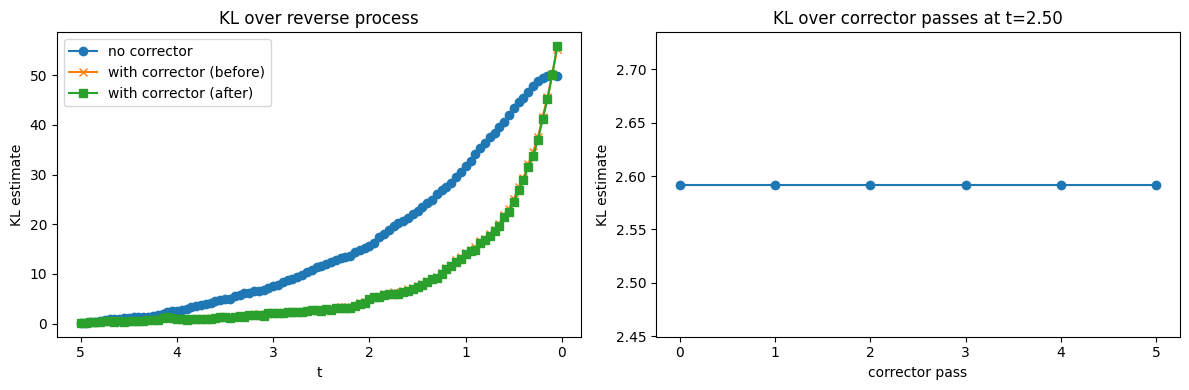

In [12]:
# test parameters - small values for quick testing
r, N, L =10, 20, 20
alpha = 10.0
beta = 1.0
T = 5.0
tau = 0.01
tau_c = 0.015       # 1.5 * tau as suggested by Campbell et al.
n_corrector = 5
n_mc = 100          # small for quick test
checkpoint_every = 5
rng = np.random.default_rng(42)

# generate p_data
w, mu = generate_mixture_parameters_dir(r, N, L, alpha, rng=rng)

print("Running without corrector...")
kl_history_no_corr = KL_mc_tau_leaping_with_corrector_analysis(
    w, mu, beta, T, tau,
    corrector=False,
    checkpoint_every=checkpoint_every,
    n_mc=n_mc,
    rng=np.random.default_rng(42)
)

print("Running with corrector...")
kl_history_corr = KL_mc_tau_leaping_with_corrector_analysis(
    w, mu, beta, T, tau,
    tau_c=tau_c,
    n_corrector=n_corrector,
    corrector=True,
    corrector_type='random_masking',
    corrector_start_frac=1.0,  # apply corrector throughout for testing
    checkpoint_every=checkpoint_every,
    n_mc=n_mc,
    rng=np.random.default_rng(42)
)

# print results
print("\n--- KL history without corrector ---")
for step, kl_vals in kl_history_no_corr.items():
    t_val = T - step * tau
    print(f"step={step:3d} t={t_val:.2f} | KL={kl_vals[0]:.4f}")

print("\n--- KL history with corrector ---")
for step, kl_vals in kl_history_corr.items():
    t_val = T - step * tau
    corr_str = " -> ".join([f"{v:.4f}" for v in kl_vals])
    print(f"step={step:3d} t={t_val:.2f} | {corr_str}")

# plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left plot: KL over time, with and without corrector
steps_no_corr = list(kl_history_no_corr.keys())
steps_corr = list(kl_history_corr.keys())
kl_no_corr = [kl_history_no_corr[s][0] for s in steps_no_corr]
kl_corr_before = [kl_history_corr[s][0] for s in steps_corr]
kl_corr_after = [kl_history_corr[s][-1] for s in steps_corr]
t_vals = [T - s * tau for s in steps_no_corr]

axes[0].plot(t_vals, kl_no_corr, label='no corrector', marker='o')
axes[0].plot(t_vals, kl_corr_before, label='with corrector (before)', marker='x')
axes[0].plot(t_vals, kl_corr_after, label='with corrector (after)', marker='s')
axes[0].set_xlabel('t')
axes[0].set_ylabel('KL estimate')
axes[0].set_title('KL over reverse process')
axes[0].invert_xaxis()  # reverse x axis so time flows left to right
axes[0].legend()

# right plot: KL over corrector passes at a specific checkpoint
# pick the checkpoint closest to t=0.5*T
target_step = int(0.5 * T / tau / checkpoint_every) * checkpoint_every
if target_step in kl_history_corr:
    kl_passes = kl_history_corr[target_step]
    axes[1].plot(range(len(kl_passes)), kl_passes, marker='o')
    axes[1].set_xlabel('corrector pass')
    axes[1].set_ylabel('KL estimate')
    axes[1].set_title(f'KL over corrector passes at t={T - target_step*tau:.2f}')

plt.tight_layout()
plt.show()

# Not used anymore

In [13]:
def tau_leaping_reverse(w, mu, beta, T, tau, rng=None):
    """
    Simulate the reverse generative process using tau leaping, as described
    in Campbell et al. (A Continuous Time Framework for Discrete Denoising Models).
    
    Starting from a fully masked sequence at time T, the reverse CTMC is simulated
    backwards from t=T to t=0 using the tau leaping approximation. At each step,
    the number of transitions for each (coordinate j, token a) pair is drawn from
    a Poisson distribution with mean tau * R_hat_t(x, x_tilde), where the reverse
    rate is:
        R_hat_t(x, x_tilde) = beta * (e^{-beta*t} / (1 - e^{-beta*t})) * p_j(a)
    and p_j(a) is the conditional marginal of coordinate j under the current
    mixture posterior omega.
    
    All transitions in [t-tau, t] are collected and applied simultaneously when
    reaching t-tau, consistent with the tau leaping approximation (which assumes
    the rate and state remain constant over the interval).
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Prior mixture weights, summing to 1. Typically uniform (1/r, ..., 1/r).
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals. mu[i, j, l] is the probability of token l
        at coordinate j under component i, drawn from Dirichlet(alpha/L).
    beta : float
        Constant forward masking rate. Each unmasked coordinate transitions to
        MASK at rate beta, giving survival probability alpha_t = exp(-beta * t).
    T : float
        Terminal time of the forward process. The sequence is fully (or nearly
        fully) masked at t=T. Campbell et al. use T=1.
    tau : float
        Tau leaping step size. Smaller tau gives a more accurate approximation
        of the true reverse CTMC at the cost of more steps. Campbell et al. 
        find tau=0.004 works well for T=1, giving NFE = T/tau steps.
    rng : np.random.Generator, optional
        Random number generator. If None, a new default generator is created.
    
    Returns
    -------
    x_t : np.ndarray, shape (N,), dtype int
        Generated sequence with values in {0, ..., L-1}. All coordinates are
        unmasked by the end of the reverse process.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    MASK = -1
    r, N, L = mu.shape
    
    # start fully masked at t=T
    x_t = np.full(N, MASK)
    omega = w.copy()
    
    t = T
    while t > 1e-3:  # stop at small epsilon to avoid rate blowup as t -> 0
        alpha_t = np.exp(-beta * t)
        rate_scalar = beta * alpha_t / (1 - alpha_t)
        
        masked = [j for j in range(N) if x_t[j] == MASK]
        if len(masked) == 0:
            break
        
        # compute conditional marginals p_j and entropies under current omega
        p_all, _, _ = compute_conditionals_and_entropies(omega, mu, masked)
        
        # collect all transitions before applying them (tau leaping: apply simultaneously)
        transitions = {}
        for j in masked:
            for a in range(L):
                # poisson draw for each (coordinate, token) pair (so for each possible transition i (from the Campbell paper))
                rate_ja = rate_scalar * p_all[j][a]
                n = rng.poisson(tau * rate_ja)
                if n > 0:
                    # if multiple tokens win for same j, last one is used (doesn't matter much since tau is small and collisions are rare) (POSSIBLE THING TO DISCUSS WITH)
                    transitions[j] = a
        
        # apply all transitions simultaneously at t - tau
        block = list(transitions.keys())
        if block:
            for j, a in transitions.items():
                x_t[j] = a
            omega = _update_omega(omega, mu, block, x_t)
        
        t = max(t - tau, 0)
    
    # final cleanup: sample any remaining masked coordinates directly from p_j
    masked = [j for j in range(N) if x_t[j] == MASK]
    if len(masked) > 0:
        p_all, _, _ = compute_conditionals_and_entropies(omega, masked, mu)
        for j in masked:
            x_t[j] = rng.choice(L, p=p_all[j])
    
    return x_t

# another try

In [14]:
def forward_marginal(x_t, beta, delta_t, rng=None):
    """
    Corrupt x_t to time t + delta_t using the forward masking process.
    Each coordinate j is masked independently with probability 1 - e^{-beta*(delta_t)}.
    
    Parameters
    ----------
    x_t : np.ndarray, shape (N,)
        Current sequence state, with MASK=-1
    beta : float
        Forward masking rate.
    delta_t : float
        Time to corrupt to.
    rng : np.random.Generator, optional
    
    Returns
    -------
    x_t_delta_t : np.ndarray, shape (N,)
        Corrupted sample with some coordinates masked.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    MASK = -1
    alpha_dt = np.exp(-beta * delta_t)
    x_t_delta_t = x_t.copy()
    mask = rng.random(len(x_t)) < (1 - alpha_dt)
    x_t_delta_t[mask] = MASK
    return x_t_delta_t

In [15]:
def pregenerate_forward_samples(w, mu, beta, T, tau, checkpoint_every, n_mc, rngs):
    """
    Pre-generate forward process samples at all checkpoint times for n_mc
    independent trajectories.
    
    Starting from x_0 ~ pi, each sample is incrementally corrupted through
    all checkpoint times using the forward masking process. This allows
    computing the true q_t marginal samples needed for KL estimation at
    each checkpoint.
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Prior mixture weights.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    beta : float
        Forward masking rate.
    T : float
        Terminal time of forward process.
    tau : float
        Predictor step size.
    checkpoint_every : int
        Number of steps between checkpoints.
    n_mc : int
        Number of independent trajectories.
    rngs : list of np.random.Generator
        Independent random generators for each trajectory, length n_mc.
    
    Returns
    -------
    x_forward : list of lists
        x_forward[m][k] is the forward sample for trajectory m at checkpoint k,
        corrupted to time t_k = k * checkpoint_every * tau.
    checkpoint_steps : list of int
        Step indices of all checkpoints.
    """
    n_steps = int(T / tau)
    checkpoint_steps = list(range(0, n_steps, checkpoint_every))
    delta_t = checkpoint_every * tau
    
    x_forward = []
    for m in range(n_mc):
        # sample x_0 from pi
        x_0 = sample_from_pi(w, mu, rng=rngs[m])
        
        # incrementally corrupt through all checkpoints
        samples_m = [x_0.copy()]
        x_current = x_0.copy()
        for _ in checkpoint_steps[1:]:
            x_current = forward_marginal(x_current, beta, delta_t, rng=rngs[m])
            samples_m.append(x_current.copy())
        
        x_forward.append(samples_m)
    
    return x_forward, checkpoint_steps

In [20]:
def log_qhat_of_xt(x_t, omega, mu, MASK=-1):
    """
    Approximate log q_hat_t(x_t) using current posterior omega.
    
    log q_hat_t(x_t) ≈ sum_{j not in M(x_t)} log p_j(x_t^j)
    where p_j(l) = sum_i omega_i * mu_{i,j}(l)
    """
    log_qhat = 0.0
    for j in range(len(x_t)):
        if x_t[j] != MASK:
            p_j = omega @ mu[:, j, :]
            log_qhat += np.log(p_j[x_t[j]] + 1e-300)
    return log_qhat

In [16]:
def tau_leaping_reverse_with_logq(w, mu, beta, T, tau, x_tk, t_k, tau_c=0.01, n_corrector=1,
                                   corrector=False, corrector_type=None, corrector_start_frac=0.1,
                                   x_given=None, rng=None):
    """
    Simulate reverse process using tau leaping and track log q(x).
    
    If x_given is provided, the function runs in EVALUATION mode:
    it uses the given token values when unmasking coordinates, but
    still tracks the log probability of those choices under p_j.
    This allows computing log q(x) for a fixed x ~ pi, needed for
    KL estimation.
    
    If x_given is None, runs in GENERATION mode: tokens are sampled
    freely from p_j.
    
    Optionally, after each predictor step, one or more corrector steps can be
    applied. Note that corrector steps are not tracked in log_q since they
    do not unmask coordinates — they only re-mask tokens at rate beta.
    
    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Prior mixture weights.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    beta : float
        Constant forward masking rate.
    T : float
        Terminal time of forward process.
    tau : float
        Predictor step size.
    x_tk : np.ndarray, shape (N,)
        State at time t_k to start reverse simulation from. Typically obtained
        by corrupting a clean sample x_0 from p_data to time t_k using forward_marginal.
    t_k : float
        Time corresponding to x_tk. Reverse simulation runs from t=t_k down to t=0.
    tau_c : float
        Corrector step size. Only used if corrector=True. Default 0.01.
    n_corrector : int
        Number of corrector steps per predictor step. Only used if corrector=True.
    corrector : bool
        If True, apply corrector steps after each predictor step.
    corrector_type : str or None
        Type of corrector to use. Must be specified if corrector=True.
        Currently supported:
        - 'random_masking': Campbell et al. uninformed corrector. Re-masks
          unmasked tokens at rate beta (forward rate R_t only), then recomputes
          omega from scratch using remaining unmasked coordinates.
    corrector_start_frac : float
        Fraction of T below which corrector steps are applied. For example,
        corrector_start_frac=0.1 means corrector steps are only applied when
        t < 0.1 * T. Default 0.1, consistent with Campbell et al. who found
        that introducing corrector steps near the end of the reverse process
        gives the best improvement for the smallest computational cost.
        Only used if corrector=True.
    x_given : dict {j: int} or None
        If provided, fixes the token values for evaluation mode.
    rng : np.random.Generator, optional
    
    Returns
    -------
    x_t : np.ndarray, shape (N,)
        Generated (or evaluated) sequence.
    log_q : float
        Estimated log q(x) = sum_j log p_j(x^j) at time of unmasking.
    """
    # validate corrector arguments
    if corrector:
        assert corrector_type is not None, \
            "corrector_type must be specified when corrector=True"
        assert corrector_type in ['random_masking'], \
            f"unknown corrector_type '{corrector_type}'"

    if rng is None:
        rng = np.random.default_rng()

    MASK = -1
    r, N, L = mu.shape

    x_t = x_tk.copy()
    omega = w.copy()
    unmasked = [j for j in range(N) if x_tk[j] != MASK]
    omega = _update_omega(omega, mu, unmasked, x_tk)  # initialize omega based on x_tk
    log_q = 0.0

    t = t_k
    while t > 1e-3:
        alpha_t = np.exp(-beta * t)
        rate_scalar = beta * alpha_t / (1 - alpha_t)

        masked = [j for j in range(N) if x_t[j] == MASK]
        if len(masked) == 0:
            break

        p_all, _, _ = compute_conditionals_and_entropies(omega, mu, masked)

        # --- PREDICTOR: collect transitions ---
        # collect all transitions before applying them (tau leaping: apply simultaneously)
        transitions = {}
        for j in masked:
            for a in range(L):
                # poisson draw for each (coordinate, token) pair (so for each possible transition i (from the Campbell paper))
                rate_ja = rate_scalar * p_all[j][a]
                n = rng.poisson(tau * rate_ja)
                if n > 0:
                    # if multiple tokens win for same j, last one is used (doesn't matter much since tau is small and collisions are rare) (POSSIBLE THING TO DISCUSS WITH)
                    transitions[j] = a 

        # apply transitions
        if transitions:
            block = list(transitions.keys())
            for j in block:
                if x_given is not None:
                    # evaluation mode: use given token
                    a = x_given[j]
                else:
                    # generation mode: use sampled token
                    a = transitions[j]
                x_t[j] = a
                # accumulate log probability of this token choice
                log_q += np.log(p_all[j][a] + 1e-300)
            omega = _update_omega(omega, mu, block, x_t)

        # --- CORRECTOR ---
        if corrector and t < corrector_start_frac * T:
            if corrector_type == 'random_masking':
                x_t = corrector_step_rm(x_t, mu, beta, tau_c, n_corrector, rng)
                # recompute omega from scratch using remaining unmasked coords
                unmasked = [j for j in range(N) if x_t[j] != MASK]
                omega = _update_omega(w, mu, unmasked, x_t)

        t = max(t - tau, 0)

    # final cleanup
    masked = [j for j in range(N) if x_t[j] == MASK]
    if len(masked) > 0:
        p_all, _, _ = compute_conditionals_and_entropies(omega, mu, masked)
        for j in masked:
            if x_given is not None:
                a = x_given[j]
            else:
                a = rng.choice(L, p=p_all[j])
            x_t[j] = a
            log_q += np.log(p_all[j][a] + 1e-300)

    return x_t, log_q




In [17]:
def KL_mc_tau_leaping_with_corrector_analysis(
        w, mu, beta, T, tau, tau_c=0.01, n_corrector=1,
        corrector=False, corrector_type=None, corrector_start_frac=0.1,
        checkpoint_every=50, n_mc=200, rng=None):
    """
    Estimate KL(q_t || q_hat_t) at regular checkpoints during the reverse
    process, measuring how the KL evolves over corrector passes at each
    checkpoint.

    At each checkpoint step k, the KL is estimated as:
        KL(q_tk || q_hat_tk) ≈ 1/M * sum_m [log q_tk(x_tk_true_m) - log q_tk(x_tk_m)]
    where:
        - x_tk_true_m ~ q_tk via forward process (x_0 ~ pi corrupted to t_k)
        - x_tk_m comes from the reverse process trajectories

    Forward samples are pre-generated at all checkpoints before the reverse
    loop starts, by incrementally corrupting n_mc samples from pi.

    At checkpoint steps where corrector=True and t < corrector_start_frac*T,
    corrector passes are applied one at a time with KL measured after each pass.
    At non-checkpoint steps, corrector passes are applied normally.

    Parameters
    ----------
    w : np.ndarray, shape (r,)
        Prior mixture weights.
    mu : np.ndarray, shape (r, N, L)
        Mixture component marginals.
    beta : float
        Constant forward masking rate.
    T : float
        Terminal time of forward process.
    tau : float
        Predictor step size.
    tau_c : float
        Corrector step size. Only used if corrector=True. Default 0.01.
    n_corrector : int
        Number of corrector steps per predictor step. Only used if corrector=True.
    corrector : bool
        If True, apply corrector steps after each predictor step.
    corrector_type : str or None
        Type of corrector to use. Must be specified if corrector=True.
        Currently supported: 'random_masking'.
    corrector_start_frac : float
        Fraction of T below which corrector steps are applied.
        Default 0.1, consistent with Campbell et al.
    checkpoint_every : int
        Number of steps between KL measurements. Default 50.
    n_mc : int
        Number of independent reverse trajectories. Default 200.
    rng : np.random.Generator, optional

    Returns
    -------
    kl_history : dict
        Maps step index to list of KL values:
        {step: [KL_before, KL_after_pass1, ..., KL_after_pass_n_corrector]}
        If corrector=False, each entry is just [KL_before].
    """
    # validate corrector arguments
    if corrector:
        assert corrector_type is not None, \
            "corrector_type must be specified when corrector=True"
        assert corrector_type in ['random_masking'], \
            f"unknown corrector_type '{corrector_type}'"

    if rng is None:
        rng = np.random.default_rng()

    MASK = -1
    r, N, L = mu.shape
    # spawn independent rngs for each trajectory
    rngs = [np.random.default_rng(rng.integers(int(1e9))) for _ in range(n_mc)]
    
    # spawn separate independent rngs for forward samples
    rngs_forward = [np.random.default_rng(rng.integers(int(1e9))) for _ in range(n_mc)]

    # pre-generate forward samples at all checkpoints
    x_forward, checkpoint_steps = pregenerate_forward_samples(
        w, mu, beta, T, tau, checkpoint_every, n_mc, rngs_forward
    )

    # initialize all reverse trajectories fully masked
    x_ts = [np.full(N, MASK) for _ in range(n_mc)]
    omegas = [w.copy() for _ in range(n_mc)]

    kl_history = {}
    step = 0
    t = T

    while t > 1e-3:
        alpha_t = np.exp(-beta * t)
        rate_scalar = beta * alpha_t / (1 - alpha_t)

        # --- PREDICTOR: update all trajectories ---
        for m in range(n_mc):
            masked = [j for j in range(N) if x_ts[m][j] == MASK]
            if len(masked) == 0:
                continue

            p_all, _, _ = compute_conditionals_and_entropies(omegas[m], mu, masked)

            transitions = {}
            for j in masked:
                for a in range(L):
                    rate_ja = rate_scalar * p_all[j][a]
                    n = rngs[m].poisson(tau * rate_ja)
                    if n > 0:
                        transitions[j] = a

            if transitions:
                block = list(transitions.keys())
                for j, a in transitions.items():
                    x_ts[m][j] = a
                omegas[m] = _update_omega(omegas[m], mu, block, x_ts[m])

        # --- CHECKPOINT: measure KL before corrector ---
        is_checkpoint = (step in checkpoint_steps)
        if is_checkpoint:
            # index into pre-generated forward samples
            k = checkpoint_steps.index(step)
            
            kl_vals = []
            for m in range(n_mc):
                # log q_t of forward sample (true marginal)
                log_qt_true = log_qt_of_xt(x_forward[m][k], w, mu, beta, t)
                # log q_t of reverse sample
                log_qt_reverse = log_qt_of_xt(x_ts[m], w, mu, beta, t)
                kl_vals.append(log_qt_true - log_qt_reverse)
            
            kl_at_checkpoint = [float(np.mean(kl_vals))]

        # --- CORRECTOR ---
        if corrector and t < corrector_start_frac * T:
            if corrector_type == 'random_masking':
                for pass_idx in range(n_corrector):
                    for m in range(n_mc):
                        x_ts[m] = corrector_step_rm(
                            x_ts[m], mu, beta, tau_c, 1, rngs[m]
                        )
                        unmasked = [j for j in range(N) if x_ts[m][j] != MASK]
                        omegas[m] = _update_omega(w, mu, unmasked, x_ts[m])

                    # measure KL after this corrector pass at checkpoints
                    if is_checkpoint:
                        kl_vals = []
                        for m in range(n_mc):
                            k = checkpoint_steps.index(step)
                            log_qt_true = log_qt_of_xt(x_forward[m][k], w, mu, beta, t)
                            log_qt_reverse = log_qt_of_xt(x_ts[m], w, mu, beta, t)
                            kl_vals.append(log_qt_true - log_qt_reverse)
                        kl_at_checkpoint.append(float(np.mean(kl_vals)))

        if is_checkpoint:
            kl_history[step] = kl_at_checkpoint

        t = max(t - tau, 0)
        step += 1

    # final cleanup for all trajectories
    for m in range(n_mc):
        masked = [j for j in range(N) if x_ts[m][j] == MASK]
        if len(masked) > 0:
            p_all, _, _ = compute_conditionals_and_entropies(omegas[m], mu, masked)
            for j in masked:
                x_ts[m][j] = rngs[m].choice(L, p=p_all[j])

    return kl_history

In [18]:
# test parameters - small values for quick testing
r, N, L = 5, 10, 4
alpha = 10.0
beta = 1.0
T = 5.0
tau = 0.1
tau_c = 0.15
n_corrector = 3
n_mc = 20
checkpoint_every = 5
rng = np.random.default_rng(42)

# generate p_data
w, mu = generate_mixture_parameters_dir(r, N, L, alpha, rng=rng)

# run without corrector
kl_history = KL_mc_tau_leaping_with_corrector_analysis(
    w, mu, beta, T, tau,
    corrector=False,
    checkpoint_every=checkpoint_every,
    n_mc=n_mc,
    rng=np.random.default_rng(42)
)

# print results
for step, kl_vals in kl_history.items():
    t_val = T - step * tau
    print(f"step={step:3d} t={t_val:.2f} | KL={kl_vals[0]:.4f}")

step=  0 t=5.00 | KL=-63.5222
step=  5 t=4.50 | KL=-30.7319
step= 10 t=4.00 | KL=-16.8487
step= 15 t=3.50 | KL=-8.9453
step= 20 t=3.00 | KL=-4.4843
step= 25 t=2.50 | KL=-1.4565
step= 30 t=2.00 | KL=0.2983
step= 35 t=1.50 | KL=3.2689
step= 40 t=1.00 | KL=5.0426
step= 45 t=0.50 | KL=4.9419


Running without corrector...
Running with corrector (full)...
Running with corrector (end only)...


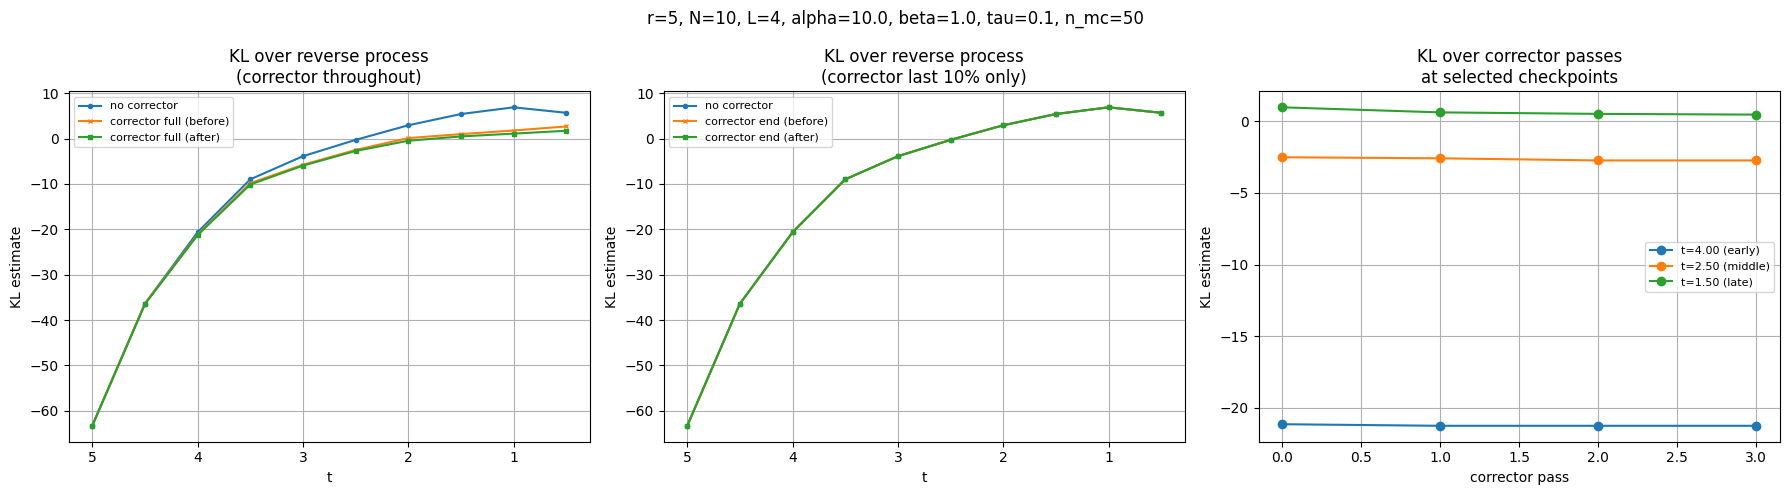


--- KL summary ---
  step      t    no corr  corr full after  corr end after
     0   5.00   -63.3076         -63.3076        -63.3076
     5   4.50   -36.3867         -36.5041        -36.3867
    10   4.00   -20.6430         -21.2757        -20.6430
    15   3.50    -8.9832         -10.1213         -8.9832
    20   3.00    -3.8833          -5.9620         -3.8833
    25   2.50    -0.2837          -2.7255         -0.2837
    30   2.00     2.9334          -0.4786          2.9334
    35   1.50     5.4141           0.4788          5.4141
    40   1.00     6.8916           1.0954          6.8916
    45   0.50     5.6835           1.7262          5.6835


In [19]:
import matplotlib.pyplot as plt

# test parameters
r, N, L = 5, 10, 4
alpha = 10.0
beta = 1.0
T = 5.0
tau = 0.1
tau_c = 0.15  # 1.5 * tau as suggested by Campbell et al.
n_corrector = 3
n_mc = 50
checkpoint_every = 5
rng = np.random.default_rng(42)

# generate p_data
w, mu = generate_mixture_parameters_dir(r, N, L, alpha, rng=rng)

# run without corrector
print("Running without corrector...")
kl_history_no_corr = KL_mc_tau_leaping_with_corrector_analysis(
    w, mu, beta, T, tau,
    corrector=False,
    checkpoint_every=checkpoint_every,
    n_mc=n_mc,
    rng=np.random.default_rng(42)
)

# run with corrector throughout
print("Running with corrector (full)...")
kl_history_corr_full = KL_mc_tau_leaping_with_corrector_analysis(
    w, mu, beta, T, tau,
    tau_c=tau_c,
    n_corrector=n_corrector,
    corrector=True,
    corrector_type='random_masking',
    corrector_start_frac=1.0,  # apply throughout
    checkpoint_every=checkpoint_every,
    n_mc=n_mc,
    rng=np.random.default_rng(42)
)

# run with corrector only near end (Campbell et al. suggestion)
print("Running with corrector (end only)...")
kl_history_corr_end = KL_mc_tau_leaping_with_corrector_analysis(
    w, mu, beta, T, tau,
    tau_c=tau_c,
    n_corrector=n_corrector,
    corrector=True,
    corrector_type='random_masking',
    corrector_start_frac=0.1,
    checkpoint_every=checkpoint_every,
    n_mc=n_mc,
    rng=np.random.default_rng(42)
)

# --- PLOT 1: KL over time for all three methods ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

steps = list(kl_history_no_corr.keys())
t_vals = [T - s * tau for s in steps]

kl_no_corr = [kl_history_no_corr[s][0] for s in steps]
kl_corr_full_before = [kl_history_corr_full[s][0] for s in steps]
kl_corr_full_after = [kl_history_corr_full[s][-1] for s in steps]
kl_corr_end_before = [kl_history_corr_end[s][0] for s in steps]
kl_corr_end_after = [kl_history_corr_end[s][-1] for s in steps]

axes[0].plot(t_vals, kl_no_corr, label='no corrector', marker='o', markersize=3)
axes[0].plot(t_vals, kl_corr_full_before, label='corrector full (before)', marker='x', markersize=3)
axes[0].plot(t_vals, kl_corr_full_after, label='corrector full (after)', marker='s', markersize=3)
axes[0].set_xlabel('t')
axes[0].set_ylabel('KL estimate')
axes[0].set_title('KL over reverse process\n(corrector throughout)')
axes[0].invert_xaxis()
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].plot(t_vals, kl_no_corr, label='no corrector', marker='o', markersize=3)
axes[1].plot(t_vals, kl_corr_end_before, label='corrector end (before)', marker='x', markersize=3)
axes[1].plot(t_vals, kl_corr_end_after, label='corrector end (after)', marker='s', markersize=3)
axes[1].set_xlabel('t')
axes[1].set_ylabel('KL estimate')
axes[1].set_title('KL over reverse process\n(corrector last 10% only)')
axes[1].invert_xaxis()
axes[1].legend(fontsize=8)
axes[1].grid(True)

# --- PLOT 2: KL over corrector passes at selected checkpoints ---
# pick 3 checkpoints: early, middle, late
all_steps = list(kl_history_corr_full.keys())
early = all_steps[len(all_steps) // 4]
middle = all_steps[len(all_steps) // 2]
late = all_steps[3 * len(all_steps) // 4]

for step_idx, label in [(early, 'early'), (middle, 'middle'), (late, 'late')]:
    if step_idx in kl_history_corr_full:
        kl_passes = kl_history_corr_full[step_idx]
        t_val = T - step_idx * tau
        axes[2].plot(range(len(kl_passes)), kl_passes, 
                    marker='o', label=f't={t_val:.2f} ({label})')

axes[2].set_xlabel('corrector pass')
axes[2].set_ylabel('KL estimate')
axes[2].set_title('KL over corrector passes\nat selected checkpoints')
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.suptitle(f'r={r}, N={N}, L={L}, alpha={alpha}, beta={beta}, tau={tau}, n_mc={n_mc}')
plt.tight_layout()
plt.show()

# --- print summary ---
print("\n--- KL summary ---")
print(f"{'step':>6} {'t':>6} {'no corr':>10} {'corr full after':>16} {'corr end after':>15}")
for s in steps:
    t_val = T - s * tau
    kl_nc = kl_history_no_corr[s][0]
    kl_cf = kl_history_corr_full[s][-1]
    kl_ce = kl_history_corr_end[s][-1]
    print(f"{s:>6} {t_val:>6.2f} {kl_nc:>10.4f} {kl_cf:>16.4f} {kl_ce:>15.4f}")